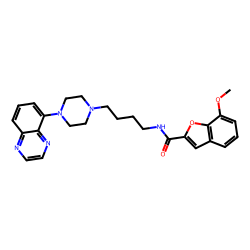

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
mol = Chem.MolFromSmiles('COc1cccc2cc(C(=O)NCCCCN3CCN(c4cccc5nccnc54)CC3)oc21')
from rdkit.Chem import Draw
Draw.MolToImage(mol,size=(250,250))

In [2]:
mol = [Chem.MolFromSmiles("c1(C=O)cc(OC)c(O)cc1"),Chem.MolFromSmiles('O=C(NCc1cc(OC)c(O)cc1)CCCC/C=C/C(C)C'),Chem.MolFromSmiles('CC(C)CCCCCC(=O)NCC1=CC(=C(C=C1)O)OC')]
from rdkit.Chem import rdFMCS
res = rdFMCS.FindMCS(mol)
print(res.numAtoms)
Chem.MolToSmiles (res.queryMol)

10


'*~*~*1~*~*(~*)~*~*~*~1~*'

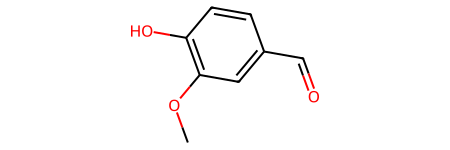

In [3]:
mol[0]

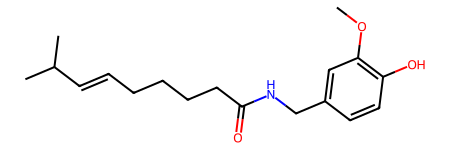

In [4]:
mol[1]

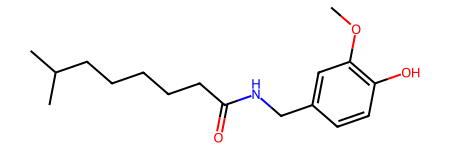

In [5]:
mol[2]

In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem

suppl = Chem.SDMolSupplier('data/cdk2.sdf')
writer = Chem.SDWriter('CDK2_3D.sdf')

for mol in suppl:
    if mol is None: continue
    
    mol = Chem.AddHs(mol)
    
    param = AllChem.ETKDGv3()
    AllChem.EmbedMultipleConfs(mol, numConfs=10, params=param)
    
    AllChem.MMFFOptimizeMoleculeConfs(mol)
    
    for conf in mol.GetConformers():
        writer.write(mol, confId=conf.GetId())

writer.close()